# NHTSA consumer complaints - what the file holds, and why its label column is two columns

**Arkon Manufacturing AI | Module: NLP Text Classification | Department: Field Quality**

This is the seventh Arkon model module and the first over free text. The six before
it read a sensor trace, a service record or a photograph. This one reads what a
member of the public wrote about their own vehicle, which changes what the module
can claim: every other module inspects a physical thing, and this one reads a
report about one.

The dataset README in `data/07_nhtsa_complaints/README.md` describes the source,
fixes the raw directory as immutable and sketches a pipeline. It also asks, in one
sentence, that the ingestion step "explicitly assign and validate the official
NHTSA column schema before using it". This notebook does that, and the validation
is not a formality: the file does not have the number of columns the published
layout has.

Everything below is measured from the file. Where a number contradicts the dataset
README or the handoff that scoped this module, the file wins.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

In [2]:
import csv
import hashlib
import os
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('../../..').resolve()
RAW = (REPO_ROOT / 'data' / '07_nhtsa_complaints' / 'raw'
       / 'COMPLAINTS_RECEIVED_2020-2024' / 'COMPLAINTS_RECEIVED_2020-2024.txt')

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

# Printed relative to the repository root. An absolute path is this machine's
# directory layout, it resolves nowhere else, and a notebook's output is tracked.
print(f'raw file : {RAW.relative_to(REPO_ROOT).as_posix()}')
print(f'size     : {os.path.getsize(RAW):,} bytes')

raw file : data/07_nhtsa_complaints/raw/COMPLAINTS_RECEIVED_2020-2024/COMPLAINTS_RECEIVED_2020-2024.txt
size     : 326,670,366 bytes


## 2. The file before any schema: bytes, lines and fields

The published NHTSA complaint layout has 49 fields. Before assigning any names, count
what is actually there. This is the same discipline the GC10 module needed when its
folder names turned out not to be its labels: the file is the authority, and a schema
is a claim about it.

In [3]:
# One byte-level pass. Line terminators and field counts decide whether the file can be
# read as a plain rectangle at all, and a narrative holding a raw newline would mean it
# cannot.
n_lf = n_cr = n_tab = n_nonascii = 0
with open(RAW, 'rb') as fh:
    while True:
        chunk = fh.read(8 << 20)
        if not chunk:
            break
        n_lf += chunk.count(b'\n')
        n_cr += chunk.count(b'\r')
        n_tab += chunk.count(b'\t')
        n_nonascii += sum(1 for b in chunk if b > 127)

print(f'LF line terminators : {n_lf:,}')
print(f'CR bytes            : {n_cr:,}')
print(f'tab bytes           : {n_tab:,}')
print(f'non-ASCII bytes     : {n_nonascii:,}')
print(f'tabs per line       : {n_tab / n_lf:.4f}')

LF line terminators : 418,884
CR bytes            : 0
tab bytes           : 20,944,200
non-ASCII bytes     : 387,788
tabs per line       : 50.0000


In [4]:
# Field count per physical line, read as latin-1 so the decode itself cannot fail and
# hide a structural problem behind an encoding one.
field_counts = Counter()
with open(RAW, 'r', encoding='latin-1', newline='') as fh:
    for line in fh:
        field_counts[line.rstrip('\r\n').count('\t') + 1] += 1

print('field count -> lines')
for k in sorted(field_counts):
    print(f'  {k:>3} fields : {field_counts[k]:,}')

# The whole file is one shape or it is not, and everything after this assumes it is.
assert len(field_counts) == 1, 'the file is ragged, the reader below is not valid'
N_FIELDS = next(iter(field_counts))
print(f'\nevery line carries {N_FIELDS} fields, not the 49 of the published layout')

field count -> lines
   51 fields : 418,884

every line carries 51 fields, not the 49 of the published layout


In [5]:
# Does it decode as UTF-8 under the strict codec. 387,788 high bytes surviving a strict
# decode over 326 MB is not a coincidence, and it means no encoding guess is needed.
utf8_ok = True
try:
    with open(RAW, 'r', encoding='utf-8') as fh:
        for _ in fh:
            pass
    print('strict UTF-8 decode: the whole file passes')
except UnicodeDecodeError as exc:
    utf8_ok = False
    print(f'strict UTF-8 decode FAILS: {exc}')

strict UTF-8 decode: the whole file passes


## 3. The schema, assigned from the file rather than to it

The published layout names 49 fields and every line here carries 51. Two readings are
possible: the names are misaligned by two somewhere, or there are two extra fields at
the end. They are distinguishable, because several of the 49 fields hold small closed
code sets whose values are recognisable on sight. If the recognisable ones land where
the layout says they should, the names are aligned and the extra fields are trailing.

In [6]:
NHTSA_COLUMNS = [
    'CMPLID', 'ODINO', 'MFR_NAME', 'MAKETXT', 'MODELTXT', 'YEARTXT', 'CRASH',
    'FAILDATE', 'FIRE', 'INJURED', 'DEATHS', 'COMPDESC', 'CITY', 'STATE', 'VIN',
    'DATEA', 'LDATE', 'MILES', 'OCCURENCES', 'CDESCR', 'CMPL_TYPE', 'POLICE_RPT_YN',
    'PURCH_DT', 'ORIG_OWNER_YN', 'ANTI_BRAKES_YN', 'CRUISE_CONT_YN', 'NUM_CYLS',
    'DRIVE_TRAIN', 'FUEL_SYS', 'FUEL_TYPE', 'TRANS_TYPE', 'VEH_SPEED', 'DOT',
    'TIRE_SIZE', 'LOC_OF_TIRE', 'TIRE_FAIL_TYPE', 'ORIG_EQUIP_YN', 'MANUF_DT',
    'SEAT_TYPE', 'RESTRAINT_TYPE', 'DEALER_NAME', 'DEALER_TEL', 'DEALER_CITY',
    'DEALER_STATE', 'DEALER_ZIP', 'PROD_TYPE', 'REPAIRED_YN', 'MEDICAL_ATTN',
    'VEHICLES_TOWED_YN',
]
# The two the published layout does not name. Named here so the reader is explicit
# about them rather than letting pandas invent an integer name.
TRAILING = ['UNNAMED_50', 'UNNAMED_51']
COLUMNS = NHTSA_COLUMNS + TRAILING
assert len(COLUMNS) == N_FIELDS, f'{len(COLUMNS)} names for {N_FIELDS} fields'
print(f'{len(NHTSA_COLUMNS)} published names plus {len(TRAILING)} unnamed trailing fields')

49 published names plus 2 unnamed trailing fields


In [7]:
# Four fields whose value sets are small, closed and recognisable. If the alignment were
# wrong these would be full of dates or free text instead.
PROBE = {'CMPL_TYPE': 'how the complaint arrived',
         'DRIVE_TRAIN': 'drive layout',
         'FUEL_TYPE': 'fuel',
         'PROD_TYPE': 'what the complaint is about'}
probe_counts = {name: Counter() for name in PROBE}
positions = {name: COLUMNS.index(name) for name in PROBE}
trailing_nonempty = Counter()
trailing_pos = [COLUMNS.index(name) for name in TRAILING]

with open(RAW, 'r', encoding='utf-8', newline='') as fh:
    for line in fh:
        parts = line.rstrip('\n').split('\t')
        for name, idx in positions.items():
            probe_counts[name][parts[idx]] += 1
        for name, idx in zip(TRAILING, trailing_pos):
            if parts[idx] != '':
                trailing_nonempty[name] += 1

for name, meaning in PROBE.items():
    top = probe_counts[name].most_common(6)
    shown = ', '.join(f'{k or "(empty)"}={v:,}' for k, v in top)
    print(f'{name:<12} ({meaning})')
    print(f'  {len(probe_counts[name])} distinct: {shown}')

CMPL_TYPE    (how the complaint arrived)
  8 distinct: IVOQ=338,362, EVOQ=79,691, LETR=725, CON=40, SVOQ=33, MIVQ=25
DRIVE_TRAIN  (drive layout)
  6 distinct: (empty)=390,839, FWD=13,726, RWD=7,993, AWD=6,131, 4WD=193, U=2
FUEL_TYPE    (fuel)
  6 distinct: (empty)=390,669, GS=23,311, HE=2,565, DS=1,455, BF=881, CN=3
PROD_TYPE    (what the complaint is about)
  5 distinct: V=413,239, T=3,091, E=1,696, C=851, (empty)=7


In [8]:
# The two unnamed fields carry nothing at all, on every line in the file.
total_lines = sum(field_counts.values())
for name in TRAILING:
    print(f'{name}: {trailing_nonempty[name]:,} non-empty values in {total_lines:,} lines')

assert sum(trailing_nonempty.values()) == 0
print('\nThe published 49 names align with the data and the file carries two trailing')
print('empty fields. A reader given 49 names for 51 columns would fail or silently')
print('shift; a reader given 51 names is correct and the last two can be dropped.')

UNNAMED_50: 0 non-empty values in 418,884 lines
UNNAMED_51: 0 non-empty values in 418,884 lines

The published 49 names align with the data and the file carries two trailing
empty fields. A reader given 49 names for 51 columns would fail or silently
shift; a reader given 51 names is correct and the last two can be dropped.


## 4. Reading it, and the two default settings that corrupt it

Two of `read_csv`'s defaults are wrong for this file and neither announces itself.

In [9]:
# The default quote handling treats a double quote inside a narrative as the start of a
# quoted field and swallows the tabs and newlines until the next one.
naive = pd.read_csv(RAW, sep='\t', header=None, dtype=str, usecols=[0], nrows=None)
print(f'default quoting : {len(naive):,} rows')
print(f'the file has    : {total_lines:,} lines')
print(f'lost silently   : {total_lines - len(naive):,} rows, with no warning and no error')

default quoting : 418,806 rows
the file has    : 418,884 lines
lost silently   : 78 rows, with no warning and no error


In [10]:
# The whole read, with both defaults corrected. keep_default_na matters because a
# narrative whose entire text is "N/A" is a real narrative, and the default turns it
# into a missing value.
USECOLS = ['CMPLID', 'ODINO', 'MFR_NAME', 'MAKETXT', 'MODELTXT', 'YEARTXT', 'CRASH',
           'FAILDATE', 'FIRE', 'INJURED', 'DEATHS', 'COMPDESC', 'DATEA', 'CDESCR',
           'PROD_TYPE']

df = pd.read_csv(RAW, sep='\t', header=None, names=COLUMNS, dtype=str,
                 quoting=csv.QUOTE_NONE, keep_default_na=False, na_values=[],
                 usecols=USECOLS)

print(f'rows read: {len(df):,}')
assert len(df) == total_lines, 'the reader lost rows'
print(f'columns  : {len(df.columns)}')
print(f'missing values anywhere: {int(df.isna().sum().sum())}')

# A narrative of literally "N/A" is text somebody typed, not an absent value.
na_text = df.loc[df['CDESCR'].str.upper().str.strip().isin(['N/A', 'NA', 'NONE', 'NULL']), 'CDESCR']
print(f'narratives whose whole text is N/A, NA, NONE or NULL: {len(na_text):,}')
print('these survive only because keep_default_na is off')

rows read: 418,884
columns  : 15


missing values anywhere: 0


narratives whose whole text is N/A, NA, NONE or NULL: 50
these survive only because keep_default_na is off


In [11]:
df.head(3).T.head(15)

,0,1,2
CMPLID,1633421,1633422,1633423
ODINO,11292384,11292384,11292384
MFR_NAME,Honda (American Honda Motor Co.),Honda (American Honda Motor Co.),Honda (American Honda Motor Co.)
MAKETXT,HONDA,HONDA,HONDA
MODELTXT,ACCORD,ACCORD,ACCORD
YEARTXT,2018,2018,2018
CRASH,N,N,N
FAILDATE,20191221,20191221,20191221
FIRE,N,N,N
INJURED,0,0,0


## 5. The row is not the complaint, and the duplication is exact

The dataset README states that one complaint may appear in several rows when it
references several components. That is a sentence about the label. It is also a
sentence about the text, and the second consequence is the one that decides how this
module is trained.

In [12]:
n_rows = len(df)
n_complaints = df['ODINO'].nunique()
n_narratives = df['CDESCR'].nunique()

print(f'rows                : {n_rows:,}')
print(f'distinct complaints : {n_complaints:,}')
print(f'distinct narratives : {n_narratives:,}')
print(f'rows above complaints: {n_rows - n_complaints:,}')

rows                : 418,884
distinct complaints : 291,999
distinct narratives : 289,315
rows above complaints: 126,885


In [13]:
# Is the repeated text identical, or merely similar. GC10 could not answer the
# equivalent question because nothing in it was identical and similarity ran as a
# continuous ridge. Here the answer is exact, which makes the split unit a fact rather
# than a judgement.
first_narr = df.groupby('ODINO')['CDESCR'].transform('first')
identical = int((df['CDESCR'] == first_narr).sum()) - n_complaints

print(f'extra rows                          : {n_rows - n_complaints:,}')
print(f'extra rows whose narrative is byte-identical to the first row of the same')
print(f'complaint                           : {identical:,}')
print(f'extra rows carrying different text  : {n_rows - n_complaints - identical:,}')

extra rows                          : 126,885
extra rows whose narrative is byte-identical to the first row of the same
complaint                           : 126,885
extra rows carrying different text  : 0


In [14]:
per_complaint = df.groupby('ODINO').size()
print('rows per complaint:')
for k, v in per_complaint.value_counts().sort_index().items():
    print(f'  {k:>2} row(s): {v:,} complaints')

labels_per = df.groupby('ODINO')['COMPDESC'].nunique()
print('\ndistinct COMPDESC values per complaint:')
for k, v in labels_per.value_counts().sort_index().items():
    print(f'  {k:>2} label(s): {v:,} complaints')
multi = int((labels_per > 1).sum())
print(f'\ncomplaints naming more than one component: {multi:,} '
      f'({100 * multi / n_complaints:.1f}% of complaints)')

rows per complaint:
   1 row(s): 201,652 complaints
   2 row(s): 54,446 complaints
   3 row(s): 35,403 complaints
   4 row(s): 406 complaints
   5 row(s): 49 complaints
   6 row(s): 41 complaints
   7 row(s): 1 complaints
   9 row(s): 1 complaints



distinct COMPDESC values per complaint:
   1 label(s): 203,814 complaints
   2 label(s): 52,995 complaints
   3 label(s): 35,135 complaints
   4 label(s): 44 complaints
   5 label(s): 9 complaints
   6 label(s): 1 complaints
   9 label(s): 1 complaints

complaints naming more than one component: 88,185 (30.2% of complaints)


**What this settles.** Training on rows would put byte-identical text on both sides of
any split that does not respect the complaint id, and it would do so tens of thousands
of times. The unit is the complaint, and the target is a set of components rather than
one, because 30 per cent of complaints name more than one.

## 6. The label column, and how much of it there is

In [15]:
print(f'distinct COMPDESC values (raw)        : {df["COMPDESC"].nunique():,}')
top_segment = df['COMPDESC'].str.split(':').str[0].str.strip()
df['COMPONENT'] = top_segment
print(f'distinct values before the first colon: {top_segment.nunique():,}')

share = top_segment.value_counts()
cum = share.cumsum() / share.sum()
print(f'\n{"component":<44}{"rows":>9}{"share":>8}{"cum":>8}')
for name, count in share.head(22).items():
    print(f'{name[:43]:<44}{count:>9,}{100 * count / share.sum():7.2f}%{100 * cum[name]:7.1f}%')
print(f'\n{len(share) - 22} further values hold {share.iloc[22:].sum():,} rows between them')

distinct COMPDESC values (raw)        : 681


distinct values before the first colon: 51

component                                        rows   share     cum
ENGINE                                         59,770  14.27%   14.3%
ELECTRICAL SYSTEM                              51,262  12.24%   26.5%
UNKNOWN OR OTHER                               41,033   9.80%   36.3%
POWER TRAIN                                    39,765   9.49%   45.8%
STEERING                                       29,431   7.03%   52.8%
SERVICE BRAKES                                 25,359   6.05%   58.9%
AIR BAGS                                       19,837   4.74%   63.6%
FUEL/PROPULSION SYSTEM                         18,665   4.46%   68.1%
FORWARD COLLISION AVOIDANCE                    17,799   4.25%   72.3%
STRUCTURE                                      16,424   3.92%   76.2%
SUSPENSION                                     12,077   2.88%   79.1%
VEHICLE SPEED CONTROL                          11,565   2.76%   81.9%
EXTERIOR LIGHTING                             

`UNKNOWN OR OTHER` is the third largest value in the file. It is not a component: it
is what the form records when the person filing could not pick one, so a model
predicting it would be modelling the reporter rather than the vehicle. It is excluded
from the target in notebook 02, and the exclusion is counted there rather than
absorbed silently.

## 7. The label column is two labellings, and the seam is a date

The dataset README asks for a temporal split. A temporal split assumes the label means
the same thing at both ends of the window. That assumption is testable.

In [16]:
df['YEAR'] = df['DATEA'].str[:4]
df['MONTH'] = df['DATEA'].str[:6]

by_year = pd.crosstab(df['COMPONENT'], df['YEAR'], normalize='columns') * 100
ordered = share.index[:20]
drift = by_year.loc[ordered].round(2)
print('Share of each year\'s rows, per cent:')
print(drift.to_string())

Share of each year's rows, per cent:
YEAR                          2020   2021   2022   2023   2024
COMPDESC                                                      
ENGINE                       13.61  14.25  13.82  14.82  14.68
ELECTRICAL SYSTEM            12.58  12.96  11.58  12.06  12.11
UNKNOWN OR OTHER             10.45  10.69   9.39   9.19   9.49
POWER TRAIN                   9.59   9.12   9.60   9.42   9.66
STEERING                      8.29   7.26   6.44   7.04   6.23
SERVICE BRAKES                5.93   5.57   6.28   6.37   6.03
AIR BAGS                      6.23   5.21   4.10   4.22   4.11
FUEL/PROPULSION SYSTEM        5.49   4.60   3.75   4.04   4.42
FORWARD COLLISION AVOIDANCE   0.47   2.78   7.42   5.38   4.96
STRUCTURE                     4.46   4.13   3.23   3.91   3.87
SUSPENSION                    3.55   3.85   3.03   2.34   2.04
VEHICLE SPEED CONTROL         3.00   2.65   2.83   2.78   2.57
EXTERIOR LIGHTING             3.11   2.75   2.33   2.25   2.11
VISIBILITY/WIPER  

In [17]:
# The ratio between a class's largest and smallest yearly share says how far it moved.
# A stable taxonomy would keep every class near 1.
eps = 0.01
ratio = (by_year.max(axis=1) + eps) / (by_year.min(axis=1) + eps)
worst = ratio.loc[by_year.sum(axis=1).sort_values(ascending=False).index[:20]].sort_values(ascending=False)
print('largest yearly share divided by smallest, top 20 classes by volume:')
for name, r in worst.head(10).items():
    row = by_year.loc[name]
    print(f'  {name[:42]:<44} {r:8.1f}x   ' +
          ' '.join(f'{v:5.2f}' for v in row.values))

largest yearly share divided by smallest, top 20 classes by volume:
  ENGINE AND ENGINE COOLING                        17.0x    0.18  0.65  1.72  1.68  3.30
  FORWARD COLLISION AVOIDANCE                      15.5x    0.47  2.78  7.42  5.38  4.96
  LANE DEPARTURE                                    9.1x    0.16  0.89  1.19  1.30  1.57
  SERVICE BRAKES, HYDRAULIC                         5.0x    0.32  0.91  1.11  1.25  1.65
  TIRES                                             3.0x    0.57  1.60  1.72  1.48  1.26
  VISIBILITY/WIPER                                  1.9x    3.02  2.77  2.17  2.01  1.58
  SUSPENSION                                        1.9x    3.55  3.85  3.03  2.34  2.04
  SEATS                                             1.8x    1.44  1.19  0.81  0.83  0.80
  WHEELS                                            1.6x    1.43  1.25  1.12  1.02  0.87
  AIR BAGS                                          1.5x    6.23  5.21  4.10  4.22  4.11


In [18]:
# ESC moves by a factor of 40 between years, which is too sharp to be behaviour. Where
# exactly does it move. Daily counts across the last quarter of 2020.
WATCH = ['ELECTRONIC STABILITY CONTROL (ESC)', 'FORWARD COLLISION AVOIDANCE',
         'LANE DEPARTURE', 'BACK OVER PREVENTION']
window = df[(df['DATEA'] >= '20201015') & (df['DATEA'] <= '20201130')]
daily = pd.crosstab(window['DATEA'], window['COMPONENT']).reindex(columns=WATCH, fill_value=0)
print(daily.to_string())

COMPONENT  ELECTRONIC STABILITY CONTROL (ESC)  FORWARD COLLISION AVOIDANCE  LANE DEPARTURE  BACK OVER PREVENTION
DATEA                                                                                                           
20201015                                    7                            0               0                     0
20201016                                   11                            0               0                     0
20201017                                    7                            0               0                     0
20201018                                    5                            0               0                     0
20201019                                   12                            0               0                     0
20201020                                    8                            1               0                     0
20201021                                   12                            0               0      

In [19]:
# The seam, found rather than assumed: the last day the retiring class is normal and the
# first day the arriving classes are.
esc_daily = df[df['COMPONENT'] == WATCH[0]].groupby('DATEA').size()
new_daily = df[df['COMPONENT'].isin(WATCH[1:])].groupby('DATEA').size()
in_2020 = esc_daily[(esc_daily.index >= '20201001') & (esc_daily.index < '20210101')]
last_normal = in_2020[in_2020 >= 3].index.max()
arriving = new_daily[(new_daily.index > last_normal) & (new_daily.index < '20210101')]
CUTOVER = arriving[arriving >= 3].index.min()

print(f'last day with 3 or more {WATCH[0]} rows : {last_normal}')
print(f'first day with 3 or more rows in the arriving classes: {CUTOVER}')
print(f'\nrows before {CUTOVER}: {int((df["DATEA"] < CUTOVER).sum()):,}')
print(f'rows from   {CUTOVER}: {int((df["DATEA"] >= CUTOVER).sum()):,}')

last day with 3 or more ELECTRONIC STABILITY CONTROL (ESC) rows : 20201103
first day with 3 or more rows in the arriving classes: 20201104

rows before 20201104: 70,739
rows from   20201104: 348,145


In [20]:
before = df[df['DATEA'] < CUTOVER]['COMPONENT'].value_counts()
after = df[df['DATEA'] >= CUTOVER]['COMPONENT'].value_counts()
b_share = before / before.sum() * 100
a_share = after / after.sum() * 100
comparison = pd.DataFrame({'before_%': b_share, 'after_%': a_share}).fillna(0)
comparison['ratio'] = (comparison['after_%'] + eps) / (comparison['before_%'] + eps)
moved = comparison[(comparison['before_%'] > 0.1) | (comparison['after_%'] > 0.1)]
moved = moved.sort_values('ratio')
print('Classes that moved most across the seam, both directions:')
print(pd.concat([moved.head(5), moved.tail(5)]).round(3).to_string())

Classes that moved most across the seam, both directions:
                                    before_%  after_%   ratio
COMPONENT                                                    
ELECTRONIC STABILITY CONTROL (ESC)     3.487    0.123   0.038
SEATS                                  1.487    0.904   0.610
AIR BAGS                               6.408    4.396   0.686
VISIBILITY/WIPER                       2.988    2.115   0.709
WHEELS                                 1.416    1.062   0.751
FUEL SYSTEM, DIESEL                    0.024    0.234   7.173
ENGINE AND ENGINE COOLING              0.195    1.883   9.231
BACK OVER PREVENTION                   0.076    1.044  12.209
LANE DEPARTURE                         0.017    1.258  47.030
FORWARD COLLISION AVOIDANCE            0.078    5.097  58.196


**What this settles.** The component column is not one labelling over five years. It is
one labelling until the seam and another after it, and the change is a single day
rather than a drift. The GC10 rule applies again in a new costume: the label is
whatever the file holds, and here the file holds two of them. Notebook 02 takes the
window from the seam onward and states the cost.

The seam removes the discontinuity. It does not remove the drift, and notebook 02
measures what is left of it inside the surviving window.

## 8. The narratives that are not narratives

In [21]:
df['NARR_LEN'] = df['CDESCR'].str.len()
q = df['NARR_LEN'].describe(percentiles=[.05, .25, .5, .75, .95])
print(q.round(1).to_string())
print(f'\nnarratives of 2048 characters exactly: {int((df["NARR_LEN"] == 2048).sum()):,}')
print('2048 is a cap rather than a coincidence, so the longest narratives are truncated')

count    418884.0
mean        591.1
std         438.9
min           1.0
5%           80.0
25%         271.0
50%         498.0
75%         775.0
95%        1562.0
max        2048.0

narratives of 2048 characters exactly: 986
2048 is a cap rather than a coincidence, so the longest narratives are truncated


In [22]:
short = df[df['NARR_LEN'] <= 25]['CDESCR']
print(f'narratives of 25 characters or fewer: {len(short):,}')
for text, count in Counter(short).most_common(12):
    print(f'  {count:>4}  {text!r}')

narratives of 25 characters or fewer: 3,086
   208  'Unknown '
   128  'Unknown'
   115  'UNKNOWN'
    49  'UNKNOWN '
    21  'unknown'
    18  'DEATH WOBBLE'
    14  'N/A'
    13  'Na'
    13  'unknown '
     9  'No'
     8  '.'
     8  'Death wobble'


In [23]:
# Text that is present, long enough to pass a length filter, and still carries nothing
# about a vehicle.
prefix = df['CDESCR'].str[:120]
by_prefix = prefix.groupby(prefix).agg(complaints=lambda s: df.loc[s.index, 'ODINO'].nunique())
worst_prefix = by_prefix.sort_values('complaints', ascending=False).head(6)
print('The narrative openings filed under the most distinct complaints:')
for text, row in worst_prefix.iterrows():
    print(f'  {int(row["complaints"]):>4} complaints  {text[:96]!r}')

The narrative openings filed under the most distinct complaints:
   331 complaints  'See attached document for complaint'
   234 complaints  'See attached document for complaint. '
   140 complaints  'The contact owns a 2017 Chevrolet Traverse. The contact received notification of NHTSA Campaign '
   125 complaints  'Unknown '
   110 complaints  'The contact owns a 2018 Honda CR-V. The contact received notification of NHTSA Campaign Number: '
    90 complaints  'The contact owns a 2018 Ford EcoSport. The contact received notification of NHTSA Campaign Numbe'


The largest group is `See attached document for complaint`, which is a pointer to a
document this dataset does not contain. The next largest are ODI transcriptions that
open with a fixed template, `The contact owns a ...`. Those are real complaints written
by a clerk to a formula, which is a different thing from an empty one, and notebook 02
keeps them.

## 9. The same text under different complaint ids

Section 5 showed exact duplication inside a complaint. The other direction matters for
the same reason and is not answered by splitting on the complaint id.

In [24]:
hashed = df['CDESCR'].map(lambda s: hashlib.blake2b(s.encode('utf-8'), digest_size=16).digest())
pairs = pd.DataFrame({'h': hashed, 'odino': df['ODINO'], 'year': df['YEAR']})
grouped = pairs.groupby('h').agg(complaints=('odino', 'nunique'), years=('year', 'nunique'))
cross = grouped[grouped['complaints'] > 1]

print(f'distinct narratives                        : {len(grouped):,}')
print(f'narratives filed under more than one id    : {len(cross):,}')
print(f'complaints involved                        : {int(cross["complaints"].sum()):,}')
print(f'largest group, one text under n complaints : {int(cross["complaints"].max()):,}')
print(f'groups spanning more than one year         : {int((cross["years"] > 1).sum()):,}')

distinct narratives                        : 289,315
narratives filed under more than one id    : 939
complaints involved                        : 3,623
largest group, one text under n complaints : 331
groups spanning more than one year         : 247


Small against 292,000 complaints, and not zero. A temporal split does not separate
these on its own, because a group spanning two years has members on both sides of any
date. Notebook 02 handles them explicitly rather than hoping the date does it.

## 10. Vehicles, volume and the fields that look like severity

In [25]:
print(f'distinct manufacturers : {df["MFR_NAME"].nunique():,}')
print(f'distinct make/model/year triples: {df.groupby(["MAKETXT", "MODELTXT", "YEARTXT"]).ngroups:,}')
monthly = df.groupby('MONTH').size()
yearly = df.groupby('YEAR').size()
print('\nrows by year of receipt:')
for k, v in yearly.items():
    print(f'  {k}: {v:,}')
print(f'\nvolume rises {100 * (yearly.iloc[-1] / yearly.iloc[0] - 1):.0f}% from the first year to the last,')
print('so a raw count comparison between two periods is not a like-for-like comparison')

distinct manufacturers : 612
distinct make/model/year triples: 11,822

rows by year of receipt:
  2020: 83,356
  2021: 69,128
  2022: 76,628
  2023: 91,757
  2024: 98,015

volume rises 18% from the first year to the last,
so a raw count comparison between two periods is not a like-for-like comparison


In [26]:
# Four fields that look like a severity and are not one: they are what the reporter said
# happened, and nothing in this dataset verifies any of them.
for col in ['CRASH', 'FIRE']:
    counts = df[col].value_counts()
    print(f'{col:<9} ' + ', '.join(f'{k or "(empty)"}={v:,}' for k, v in counts.items()))
for col in ['INJURED', 'DEATHS']:
    nonzero = int((pd.to_numeric(df[col], errors='coerce').fillna(0) > 0).sum())
    print(f'{col:<9} rows above zero: {nonzero:,}')
print('\nThese are reported facts, not model outputs and not verified findings.')
print('Section 5 of the model card records why they stay out of the priority rule.')

CRASH     N=399,759, Y=19,125


FIRE      N=410,869, Y=8,015


INJURED   rows above zero: 11,419


DEATHS    rows above zero: 411

These are reported facts, not model outputs and not verified findings.
Section 5 of the model card records why they stay out of the priority rule.


## 11. What the module will be able to see, and one figure

  ✓ Saved → assets\nlp\nhtsa_eda_labels.png


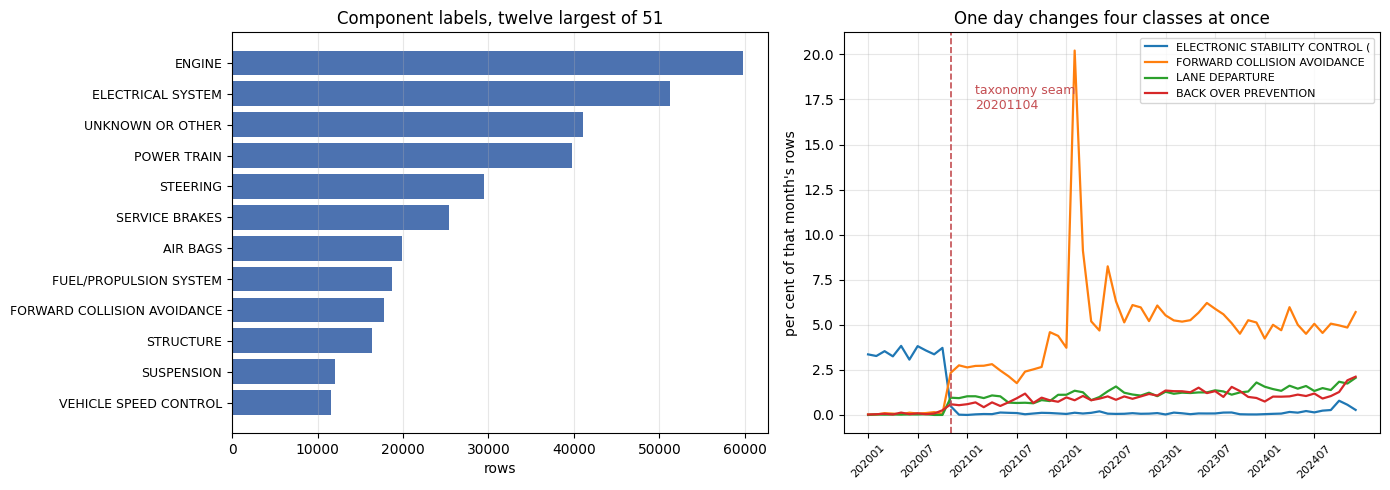

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
top12 = share.head(12)[::-1]
ax.barh(range(len(top12)), top12.values, color='#4C72B0')
ax.set_yticks(range(len(top12)))
ax.set_yticklabels([n[:34] for n in top12.index], fontsize=9)
ax.set_xlabel('rows')
ax.set_title('Component labels, twelve largest of %d' % len(share))
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
for name in WATCH:
    series = df[df['COMPONENT'] == name].groupby('MONTH').size().reindex(monthly.index, fill_value=0)
    ax.plot(range(len(series)), 100 * series / monthly.values, label=name[:30], linewidth=1.6)
cut_index = list(monthly.index).index(CUTOVER[:6])
ax.axvline(cut_index, color='#C44E52', linestyle='--', linewidth=1.2)
ax.annotate('taxonomy seam\n%s' % CUTOVER, xy=(cut_index, ax.get_ylim()[1] * 0.75),
            xytext=(cut_index + 3, ax.get_ylim()[1] * 0.8), fontsize=9, color='#C44E52')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([monthly.index[i] for i in range(0, len(monthly), 6)], rotation=45, fontsize=8)
ax.set_ylabel('per cent of that month\'s rows')
ax.set_title('One day changes four classes at once')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, 'nhtsa_eda_labels', subfolder='nlp')
plt.show()

## 12. Write the findings, so the model card reads them rather than repeating them

The card generator cannot open a 326 MB file to check a sentence, and a number retyped
into a document is a number that stops being true the moment the file changes. Every
finding above is written out here and read from there.

In [28]:
import json

facts = {
    'file': {
        'size_bytes': int(os.path.getsize(RAW)),
        'lines': int(total_lines),
        'fields_per_line': int(N_FIELDS),
        'published_layout_fields': len(NHTSA_COLUMNS),
        'trailing_empty_fields': len(TRAILING),
        'non_ascii_bytes': int(n_nonascii),
        'utf8_strict_ok': bool(utf8_ok),
    },
    'reader': {
        'rows_lost_to_default_quoting': int(total_lines - len(naive)),
        'narratives_containing_a_double_quote': int(df['CDESCR'].str.contains('"').sum()),
        'narratives_read_as_missing_by_default': int(len(na_text)),
    },
    'identity': {
        'rows': int(n_rows),
        'complaints': int(n_complaints),
        'distinct_narratives': int(n_narratives),
        'extra_rows': int(n_rows - n_complaints),
        'extra_rows_byte_identical': int(identical),
        'multi_component_complaints': int(multi),
        'multi_component_share': float(multi / n_complaints),
    },
    'labels': {
        'compdesc_values': int(df['COMPDESC'].nunique()),
        'top_segment_values': int(top_segment.nunique()),
        'unknown_or_other_rows': int(share.get('UNKNOWN OR OTHER', 0)),
        'unknown_or_other_share': float(share.get('UNKNOWN OR OTHER', 0) / share.sum()),
        'cutover': str(CUTOVER),
        'last_normal_day_retiring_class': str(last_normal),
        'retiring_class': WATCH[0],
        'arriving_classes': WATCH[1:],
        'rows_before_cutover': int((df['DATEA'] < CUTOVER).sum()),
        'seam_ratio': {name: float(comparison.loc[name, 'ratio'])
                       for name in WATCH if name in comparison.index},
    },
    'narratives': {
        'median_chars': int(df['NARR_LEN'].median()),
        'p95_chars': int(df['NARR_LEN'].quantile(0.95)),
        'cap_chars': int(df['NARR_LEN'].max()),
        'at_cap': int((df['NARR_LEN'] == 2048).sum()),
        'under_25_chars': int((df['NARR_LEN'] <= 25).sum()),
        'largest_pointer_group': int(worst_prefix['complaints'].iloc[0]),
        'largest_pointer_text': str(worst_prefix.index[0])[:60],
        'cross_complaint_narratives': int(len(cross)),
        'cross_complaint_complaints': int(cross['complaints'].sum()),
        'cross_complaint_largest': int(cross['complaints'].max()),
        'cross_complaint_multi_year_groups': int((cross['years'] > 1).sum()),
    },
    'fleet': {
        'manufacturers': int(df['MFR_NAME'].nunique()),
        'make_model_year_triples': int(df.groupby(['MAKETXT', 'MODELTXT', 'YEARTXT']).ngroups),
        'rows_by_year': {str(k): int(v) for k, v in yearly.items()},
        'volume_rise_share': float(yearly.iloc[-1] / yearly.iloc[0] - 1),
    },
    'reported_harm': {
        'crash_yes': int((df['CRASH'] == 'Y').sum()),
        'fire_yes': int((df['FIRE'] == 'Y').sum()),
        'injured_rows_above_zero': int((pd.to_numeric(df['INJURED'], errors='coerce').fillna(0) > 0).sum()),
        'deaths_rows_above_zero': int((pd.to_numeric(df['DEATHS'], errors='coerce').fillna(0) > 0).sum()),
    },
}
FACTS_PATH = REPO_ROOT / 'data' / '07_nhtsa_complaints' / 'processed' / 'nhtsa_eda_facts.json'
FACTS_PATH.parent.mkdir(parents=True, exist_ok=True)
FACTS_PATH.write_text(json.dumps(facts, indent=2), encoding='utf-8')
print(f'wrote {FACTS_PATH.relative_to(REPO_ROOT).as_posix()}')
print(f'{sum(len(v) for v in facts.values())} findings in {len(facts)} groups')

wrote data/07_nhtsa_complaints/processed/nhtsa_eda_facts.json
46 findings in 7 groups


## 13. What this notebook found

In [29]:
print('1. The file carries %d fields, not the 49 the published layout names. Fields 50'
      % N_FIELDS)
print('   and 51 are empty on every one of its %d lines. A reader given 49 names is' % total_lines)
print('   wrong, and the dataset README asks for exactly this check.')
print()
print('2. Two read_csv defaults corrupt it silently. Default quoting loses %d rows'
      % (total_lines - len(naive)))
print('   because %d narratives contain a double quote, and the default missing-value'
      % int(df['CDESCR'].str.contains('"').sum()))
print('   list turns a narrative reading N/A into an absent one.')
print()
print('3. The row is not the complaint. %d rows carry %d complaints, and all %d'
      % (n_rows, n_complaints, identical))
print('   extra rows repeat the first row\'s narrative byte for byte. The unit is the')
print('   complaint and the target is a set: %.1f%% of complaints name more than one'
      % (100 * multi / n_complaints))
print('   component.')
print()
print('4. The component column is two labellings joined at %s. On that day' % CUTOVER)
print('   %s stops and three classes start.' % WATCH[0])
print('   Splitting the five years temporally without cutting there trains a model on')
print('   two incompatible label systems at once.')
print()
print('5. %d narratives are 25 characters or shorter and %d complaints say only'
      % (int((df['NARR_LEN'] <= 25).sum()), int(worst_prefix['complaints'].iloc[0])))
print('   "See attached document for complaint". %d narratives sit at the 2048'
      % int((df['NARR_LEN'] == 2048).sum()))
print('   character cap and are truncated.')
print()
print('6. %d narratives appear under more than one complaint id, %d of those groups'
      % (len(cross), int((cross['years'] > 1).sum())))
print('   spanning more than one year, so a date-based split does not separate them.')
print()
print('7. Volume rises %.0f%% across the window, so any trend built on raw counts has'
      % (100 * (yearly.iloc[-1] / yearly.iloc[0] - 1)))
print('   to be rate-adjusted before two periods can be compared.')

1. The file carries 51 fields, not the 49 the published layout names. Fields 50
   and 51 are empty on every one of its 418884 lines. A reader given 49 names is
   wrong, and the dataset README asks for exactly this check.

2. Two read_csv defaults corrupt it silently. Default quoting loses 78 rows


   because 34696 narratives contain a double quote, and the default missing-value


   list turns a narrative reading N/A into an absent one.

3. The row is not the complaint. 418884 rows carry 291999 complaints, and all 126885
   extra rows repeat the first row's narrative byte for byte. The unit is the
   complaint and the target is a set: 30.2% of complaints name more than one
   component.

4. The component column is two labellings joined at 20201104. On that day
   ELECTRONIC STABILITY CONTROL (ESC) stops and three classes start.
   Splitting the five years temporally without cutting there trains a model on
   two incompatible label systems at once.

5. 3086 narratives are 25 characters or shorter and 331 complaints say only
   "See attached document for complaint". 986 narratives sit at the 2048
   character cap and are truncated.

6. 939 narratives appear under more than one complaint id, 247 of those groups
   spanning more than one year, so a date-based split does not separate them.

7. Volume rises 18% across the window, so any trend built on raw counts has